# Distance vs Similarity with Real Word2Vec Embeddings

## Using Pre-trained Word2Vec + PCA for 3D Visualization

## Installation

First, install required packages:

In [1]:
# Install gensim for Word2Vec
%pip install gensim numpy matplotlib scikit-learn scipy seaborn

  Using cached gensim-4.3.3-cp312-cp312-macosx_11_0_arm64.whl.metadata (8.1 kB)
  Using cached numpy-1.26.4-cp312-cp312-macosx_11_0_arm64.whl.metadata (61 kB)
  Using cached scipy-1.13.1-cp312-cp312-macosx_12_0_arm64.whl.metadata (60 kB)
  Using cached wrapt-1.17.3-cp312-cp312-macosx_11_0_arm64.whl.metadata (6.4 kB)
Using cached gensim-4.3.3-cp312-cp312-macosx_11_0_arm64.whl (24.0 MB)
Using cached numpy-1.26.4-cp312-cp312-macosx_11_0_arm64.whl (13.7 MB)
Using cached scipy-1.13.1-cp312-cp312-macosx_12_0_arm64.whl (30.4 MB)
Using cached wrapt-1.17.3-cp312-cp312-macosx_11_0_arm64.whl (39 kB)
  Attempting uninstall: numpy
    Found existing installation: numpy 2.3.3
    Uninstalling numpy-2.3.3:
      Successfully uninstalled numpy-2.3.3
  Attempting uninstall: scipym━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1/5 [numpy]
    Found existing installation: scipy 1.16.2━━━━━━━━━━━━━━━━━ 1/5 [numpy]
    Uninstalling scipy-1.16.2:m━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1/5 [numpy]
      Successfully uninstalled s

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import cosine_similarity, euclidean_distances
from scipy.spatial.distance import euclidean, cosine
import seaborn as sns
from matplotlib import cm
from matplotlib.colors import Normalize

# Import gensim for Word2Vec
import gensim.downloader as api

plt.style.use('seaborn-v0_8-darkgrid')
%matplotlib inline

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


## 1. Load Pre-trained Word2Vec Model

We'll use Google's pre-trained Word2Vec model (this may take a few minutes to download)

In [3]:
# Download pre-trained Word2Vec model
# Options: 'word2vec-google-news-300' (1.6GB) or 'glove-wiki-gigaword-50' (65MB)
# Using smaller model for faster download

print("📥 Downloading pre-trained embeddings... (this may take a minute)")
print("Using: glove-wiki-gigaword-100 (128MB)\n")

model = api.load('glove-wiki-gigaword-100')

print("\n✅ Model loaded successfully!")
print(f"Vocabulary size: {len(model)} words")
print(f"Vector dimensions: {model.vector_size}D")

📥 Downloading pre-trained embeddings... (this may take a minute)
Using: glove-wiki-gigaword-100 (128MB)

[==================================================] 100.0% 128.1/128.1MB downloaded

✅ Model loaded successfully!
Vocabulary size: 400000 words
Vector dimensions: 100D


## 2. Select Words and Extract Embeddings

Choose semantically related words from different categories

In [4]:
# Define word categories
word_groups = {
    'Animals': ['dog', 'cat', 'puppy', 'kitten', 'wolf', 'tiger'],
    'Fruits': ['apple', 'banana', 'orange', 'mango', 'grape', 'strawberry'],
    'Technology': ['computer', 'laptop', 'phone', 'tablet', 'software', 'hardware'],
    'Vehicles': ['car', 'bike', 'bus', 'train', 'truck', 'motorcycle'],
    'Sports': ['cricket', 'football', 'tennis', 'hockey', 'basketball', 'baseball']
}

# Flatten to get all words
all_words = [word for words in word_groups.values() for word in words]

# Extract embeddings
embeddings = {}
words = []

print("📊 Extracting embeddings...\n")
for word in all_words:
    if word in model:
        embeddings[word] = model[word]
        words.append(word)
        print(f"✅ {word:<15} - embedding shape: {model[word].shape}")
    else:
        print(f"❌ {word:<15} - not in vocabulary")

print(f"\n✅ Successfully loaded {len(embeddings)} word embeddings!")
print(f"Each embedding has {model.vector_size} dimensions")

📊 Extracting embeddings...

✅ dog             - embedding shape: (100,)
✅ cat             - embedding shape: (100,)
✅ puppy           - embedding shape: (100,)
✅ kitten          - embedding shape: (100,)
✅ wolf            - embedding shape: (100,)
✅ tiger           - embedding shape: (100,)
✅ apple           - embedding shape: (100,)
✅ banana          - embedding shape: (100,)
✅ orange          - embedding shape: (100,)
✅ mango           - embedding shape: (100,)
✅ grape           - embedding shape: (100,)
✅ strawberry      - embedding shape: (100,)
✅ computer        - embedding shape: (100,)
✅ laptop          - embedding shape: (100,)
✅ phone           - embedding shape: (100,)
✅ tablet          - embedding shape: (100,)
✅ software        - embedding shape: (100,)
✅ hardware        - embedding shape: (100,)
✅ car             - embedding shape: (100,)
✅ bike            - embedding shape: (100,)
✅ bus             - embedding shape: (100,)
✅ train           - embedding shape: (100,)
✅ tr

## 3. Test Word2Vec Similarity

Verify that semantically similar words have high similarity

In [5]:
# Test similar words
test_pairs = [
    ('dog', 'puppy', '🐕'),
    ('cat', 'kitten', '🐱'),
    ('computer', 'laptop', '💻'),
    ('car', 'bike', '🚗'),
    ('cricket', 'football', '⚽')
]

print("🧪 Testing Word2Vec Quality:\n")
print(f"{'Word 1':<12} {'Word 2':<12} {'Similarity':<12} {'Distance':<12}")
print("="*60)

for word1, word2, emoji in test_pairs:
    if word1 in embeddings and word2 in embeddings:
        sim = cosine_similarity([embeddings[word1]], [embeddings[word2]])[0][0]
        dist = euclidean(embeddings[word1], embeddings[word2])
        print(f"{emoji} {word1:<10} {word2:<10} {sim:>8.3f}      {dist:>8.2f}")

print("\n💡 Notice: Similar words have HIGH similarity, LOW distance!")

🧪 Testing Word2Vec Quality:

Word 1       Word 2       Similarity   Distance    
🐕 dog        puppy         0.724          3.95
🐱 cat        kitten        0.558          4.45
💻 computer   laptop        0.702          4.71
🚗 car        bike          0.632          5.14
⚽ cricket    football      0.666          5.27

💡 Notice: Similar words have HIGH similarity, LOW distance!


## 4. Apply PCA to Reduce to 3D

Reduce high-dimensional Word2Vec embeddings (100D) to 3D for visualization

In [6]:
# Prepare embedding matrix
embedding_matrix = np.array([embeddings[word] for word in words])

print(f"Original shape: {embedding_matrix.shape}")
print(f"  {len(words)} words × {model.vector_size} dimensions\n")

# Apply PCA
pca = PCA(n_components=3)
embeddings_3d = pca.fit_transform(embedding_matrix)

# Create dictionary for easy access
embeddings_3d_dict = {word: embeddings_3d[i] for i, word in enumerate(words)}

print(f"Reduced shape: {embeddings_3d.shape}")
print(f"  {len(words)} words × 3 dimensions\n")

print("📊 Variance Explained:")
print(f"  PC1: {pca.explained_variance_ratio_[0]:.2%}")
print(f"  PC2: {pca.explained_variance_ratio_[1]:.2%}")
print(f"  PC3: {pca.explained_variance_ratio_[2]:.2%}")
print(f"  Total: {pca.explained_variance_ratio_.sum():.2%}")

print("\n💡 PCA captured the most important patterns in just 3 dimensions!")

Original shape: (30, 100)
  30 words × 100 dimensions

Reduced shape: (30, 3)
  30 words × 3 dimensions

📊 Variance Explained:
  PC1: 19.35%
  PC2: 15.90%
  PC3: 13.51%
  Total: 48.76%

💡 PCA captured the most important patterns in just 3 dimensions!


## 5. 3D Visualization - Semantic Clusters

Visualize how semantically similar words cluster together

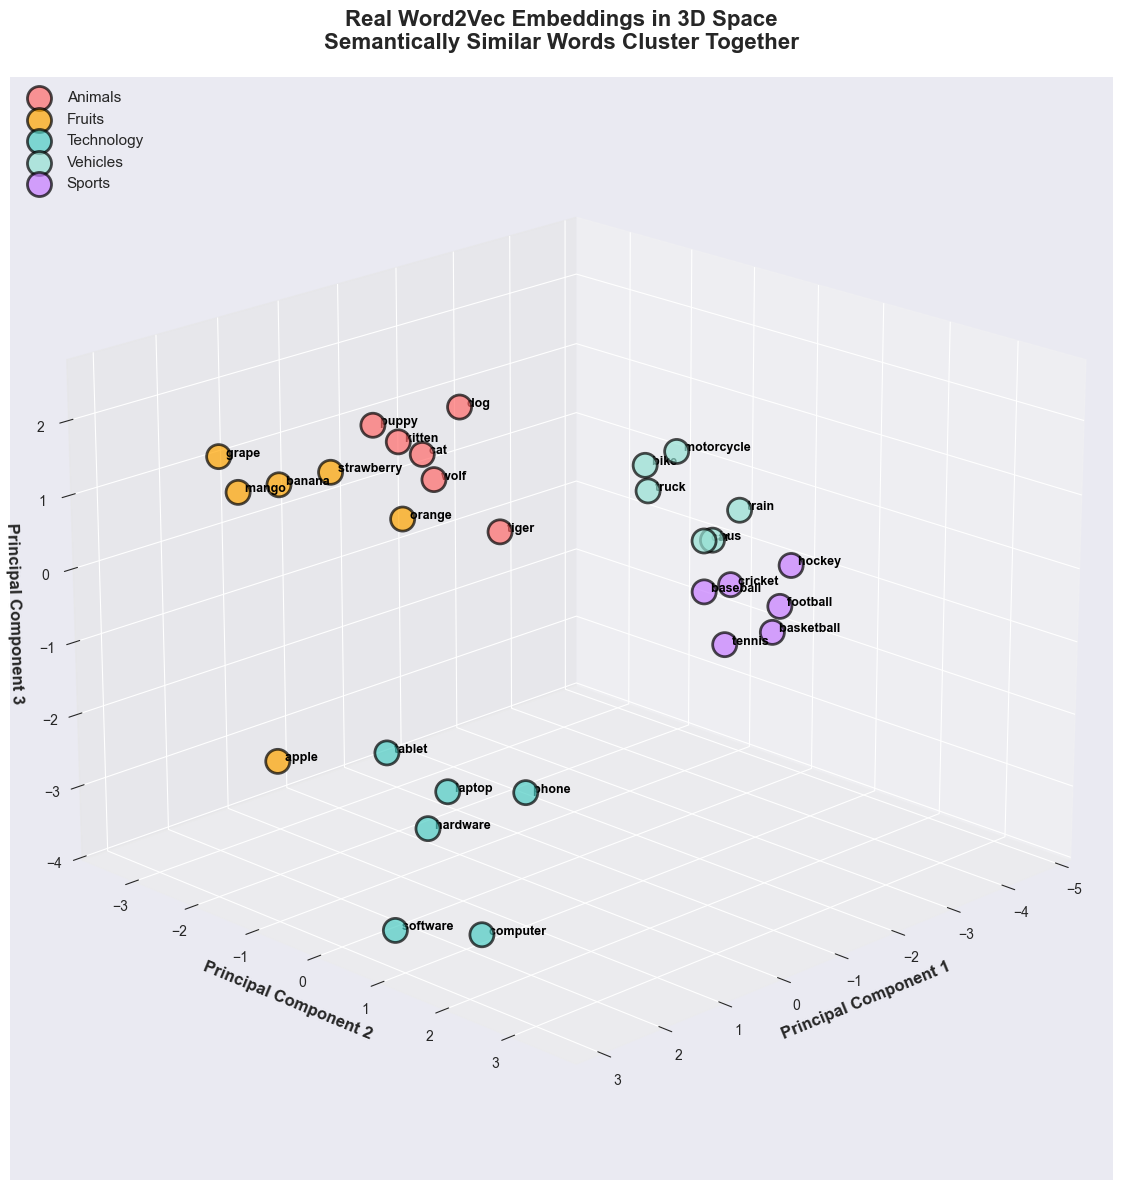


💡 Observation: Words with similar meanings cluster together!
   This is the power of Word2Vec - it captures semantic relationships!


In [7]:
# Define colors for each category
colors_map = {
    'Animals': '#FF6B6B',
    'Fruits': '#FFA500',
    'Technology': '#4ECDC4',
    'Vehicles': '#95E1D3',
    'Sports': '#C77DFF'
}

# Create 3D plot
fig = plt.figure(figsize=(16, 12))
ax = fig.add_subplot(111, projection='3d')

# Plot each category
for category, word_list in word_groups.items():
    # Filter words that exist in embeddings
    available_words = [w for w in word_list if w in embeddings_3d_dict]
    if not available_words:
        continue
    
    points = np.array([embeddings_3d_dict[word] for word in available_words])
    
    ax.scatter(points[:, 0], points[:, 1], points[:, 2],
              c=colors_map[category], s=300, alpha=0.7,
              label=category, edgecolors='black', linewidth=2)
    
    # Add word labels
    for word in available_words:
        point = embeddings_3d_dict[word]
        ax.text(point[0], point[1], point[2], f'  {word}',
               fontsize=9, weight='bold', color='black')

ax.set_xlabel('Principal Component 1', fontsize=12, weight='bold')
ax.set_ylabel('Principal Component 2', fontsize=12, weight='bold')
ax.set_zlabel('Principal Component 3', fontsize=12, weight='bold')
ax.set_title('Real Word2Vec Embeddings in 3D Space\nSemantically Similar Words Cluster Together',
            fontsize=16, weight='bold', pad=20)
ax.legend(fontsize=11, loc='upper left')

# Better viewing angle
ax.view_init(elev=20, azim=45)

plt.tight_layout()
plt.show()

print("\n💡 Observation: Words with similar meanings cluster together!")
print("   This is the power of Word2Vec - it captures semantic relationships!")

## 6. Distance Visualization from Reference Word

Show distances from a reference word - **GREEN = CLOSE, RED = FAR**

/var/folders/62/mgtn51r97gl21dm8hd8ywt2h0000gq/T/ipykernel_45121/1948359312.py:20: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('RdYlGn_r')  # Red = far, Green = close
/var/folders/62/mgtn51r97gl21dm8hd8ywt2h0000gq/T/ipykernel_45121/1948359312.py:57: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/62/mgtn51r97gl21dm8hd8ywt2h0000gq/T/ipykernel_45121/1948359312.py:57: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) Arial.
  plt.tight_layout()
/Users/durgesh.rathod/Documents/personal/youtube/youtube-tutorials-notebooks/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/User

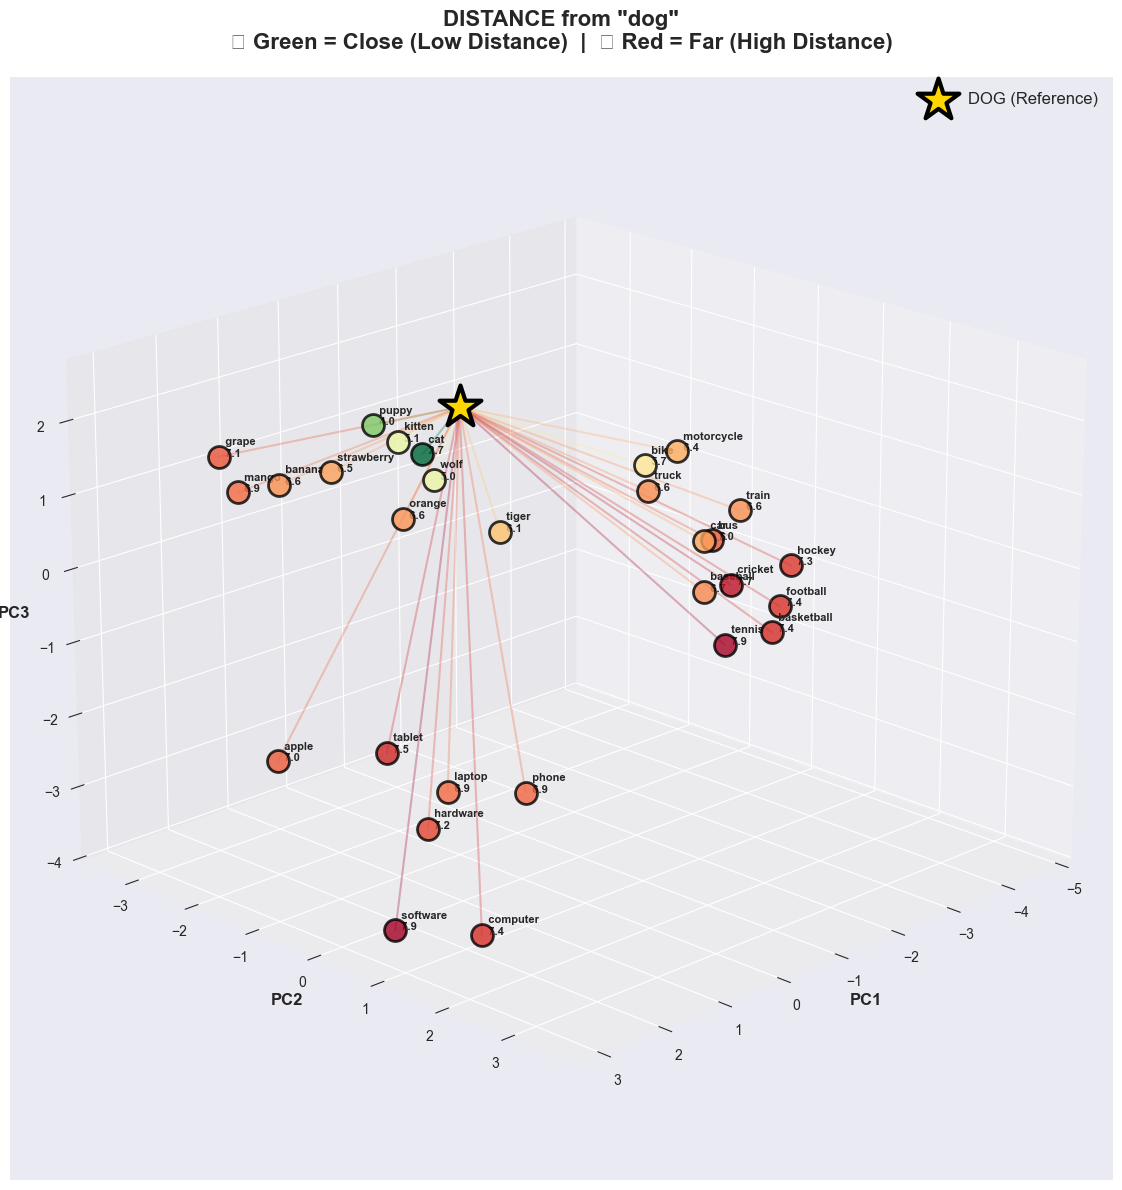


📏 DISTANCES from 'dog' (Lower = Closer):

Rank   Word            Distance     Category
🟢 1    cat             2.68         Animals
🟢 2    puppy           3.95         Animals
🟢 3    wolf            5.04         Animals
🟢 4    kitten          5.06         Animals
🟢 5    bike            5.71         Vehicles
🟢 6    tiger           6.14         Animals
🟢 7    motorcycle      6.37         Vehicles
🟢 8    strawberry      6.46         Fruits
🟢 9    car             6.46         Vehicles
🟢 10   orange          6.56         Fruits


In [8]:
# Choose reference word
reference_word = 'dog'
reference_point = embeddings_3d_dict[reference_word]
reference_embedding = embeddings[reference_word]

# Calculate distances
distances = {}
for word in words:
    if word != reference_word:
        dist = euclidean(reference_embedding, embeddings[word])
        distances[word] = dist

# Create 3D plot colored by distance
fig = plt.figure(figsize=(16, 12))
ax = fig.add_subplot(111, projection='3d')

# Normalize for color mapping
dist_values = list(distances.values())
norm = Normalize(vmin=min(dist_values), vmax=max(dist_values))
cmap = cm.get_cmap('RdYlGn_r')  # Red = far, Green = close

# Plot reference word
ax.scatter(reference_point[0], reference_point[1], reference_point[2],
          c='gold', s=1000, marker='*', edgecolors='black',
          linewidth=3, label=f'{reference_word.upper()} (Reference)', zorder=10)

# Plot other words
for word in words:
    if word != reference_word:
        point = embeddings_3d_dict[word]
        dist = distances[word]
        color = cmap(norm(dist))
        
        ax.scatter(point[0], point[1], point[2],
                  c=[color], s=250, alpha=0.8,
                  edgecolors='black', linewidth=2)
        
        # Draw line to reference
        ax.plot([reference_point[0], point[0]],
               [reference_point[1], point[1]],
               [reference_point[2], point[2]],
               color=color, alpha=0.3, linewidth=1.5)
        
        # Label with distance
        ax.text(point[0], point[1], point[2],
               f'  {word}\n  {dist:.1f}',
               fontsize=8, weight='bold')

ax.set_xlabel('PC1', fontsize=12, weight='bold')
ax.set_ylabel('PC2', fontsize=12, weight='bold')
ax.set_zlabel('PC3', fontsize=12, weight='bold')
ax.set_title(f'DISTANCE from "{reference_word}"\n🟢 Green = Close (Low Distance)  |  🔴 Red = Far (High Distance)',
            fontsize=16, weight='bold', pad=20)
ax.legend(fontsize=12)
ax.view_init(elev=20, azim=45)

plt.tight_layout()
plt.show()

# Print rankings
sorted_dist = sorted(distances.items(), key=lambda x: x[1])
print(f"\n📏 DISTANCES from '{reference_word}' (Lower = Closer):\n")
print(f"{'Rank':<6} {'Word':<15} {'Distance':<12} {'Category'}")
print("="*50)
for i, (word, dist) in enumerate(sorted_dist[:10], 1):
    # Find category
    cat = next((c for c, ws in word_groups.items() if word in ws), 'Unknown')
    emoji = '🟢' if dist < np.median(dist_values) else '🔴'
    print(f"{emoji} {i:<4} {word:<15} {dist:<12.2f} {cat}")

## 7. Similarity Visualization - INVERSE of Distance

Same data, but viewed through similarity - **GREEN = SIMILAR, RED = DIFFERENT**

/var/folders/62/mgtn51r97gl21dm8hd8ywt2h0000gq/T/ipykernel_45121/60262811.py:15: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('RdYlGn')  # Red = low similarity, Green = high similarity
/var/folders/62/mgtn51r97gl21dm8hd8ywt2h0000gq/T/ipykernel_45121/60262811.py:52: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/62/mgtn51r97gl21dm8hd8ywt2h0000gq/T/ipykernel_45121/60262811.py:52: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) Arial.
  plt.tight_layout()
/Users/durgesh.rathod/Documents/personal/youtube/youtube-tutorials-notebooks/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io

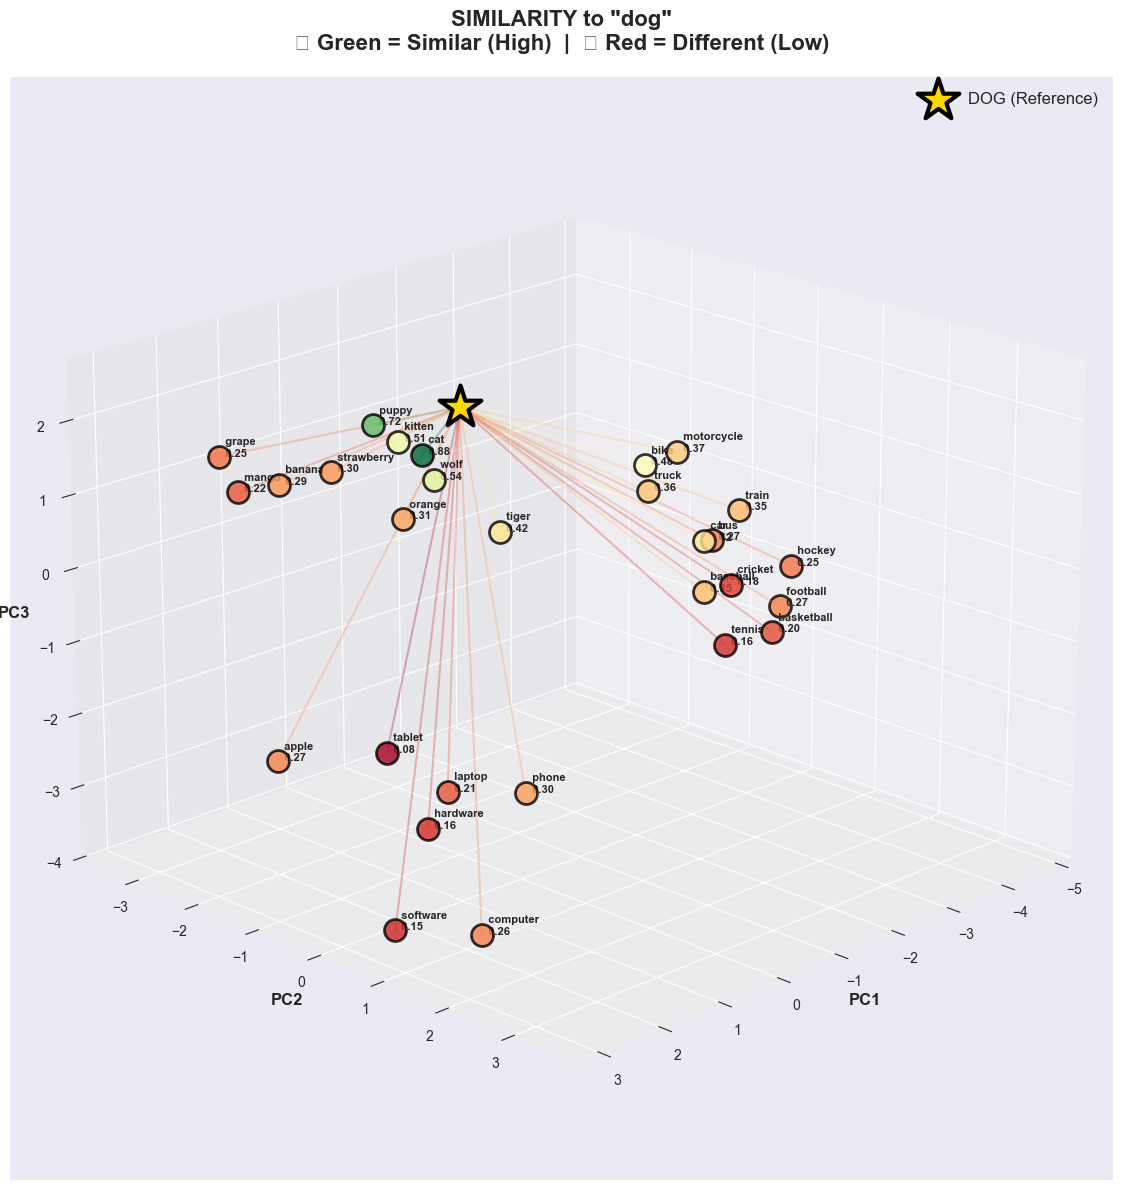


🔗 SIMILARITIES to 'dog' (Higher = More Similar):

Rank   Word            Similarity   Category
🟢 1    cat             0.880        Animals
🟢 2    puppy           0.724        Animals
🟢 3    wolf            0.537        Animals
🟢 4    kitten          0.511        Animals
🟢 5    bike            0.479        Vehicles
🟢 6    car             0.421        Vehicles
🟢 7    tiger           0.416        Animals
🟢 8    motorcycle      0.367        Vehicles
🟢 9    truck           0.359        Vehicles
🟢 10   baseball        0.347        Sports


In [9]:
# Calculate similarities
similarities = {}
for word in words:
    if word != reference_word:
        sim = cosine_similarity([reference_embedding], [embeddings[word]])[0][0]
        similarities[word] = sim

# Create 3D plot colored by similarity
fig = plt.figure(figsize=(16, 12))
ax = fig.add_subplot(111, projection='3d')

# Normalize for color mapping
sim_values = list(similarities.values())
norm = Normalize(vmin=min(sim_values), vmax=max(sim_values))
cmap = cm.get_cmap('RdYlGn')  # Red = low similarity, Green = high similarity

# Plot reference word
ax.scatter(reference_point[0], reference_point[1], reference_point[2],
          c='gold', s=1000, marker='*', edgecolors='black',
          linewidth=3, label=f'{reference_word.upper()} (Reference)', zorder=10)

# Plot other words
for word in words:
    if word != reference_word:
        point = embeddings_3d_dict[word]
        sim = similarities[word]
        color = cmap(norm(sim))
        
        ax.scatter(point[0], point[1], point[2],
                  c=[color], s=250, alpha=0.8,
                  edgecolors='black', linewidth=2)
        
        # Draw line to reference
        ax.plot([reference_point[0], point[0]],
               [reference_point[1], point[1]],
               [reference_point[2], point[2]],
               color=color, alpha=0.3, linewidth=1.5)
        
        # Label with similarity
        ax.text(point[0], point[1], point[2],
               f'  {word}\n  {sim:.2f}',
               fontsize=8, weight='bold')

ax.set_xlabel('PC1', fontsize=12, weight='bold')
ax.set_ylabel('PC2', fontsize=12, weight='bold')
ax.set_zlabel('PC3', fontsize=12, weight='bold')
ax.set_title(f'SIMILARITY to "{reference_word}"\n🟢 Green = Similar (High)  |  🔴 Red = Different (Low)',
            fontsize=16, weight='bold', pad=20)
ax.legend(fontsize=12)
ax.view_init(elev=20, azim=45)

plt.tight_layout()
plt.show()

# Print rankings
sorted_sim = sorted(similarities.items(), key=lambda x: x[1], reverse=True)
print(f"\n🔗 SIMILARITIES to '{reference_word}' (Higher = More Similar):\n")
print(f"{'Rank':<6} {'Word':<15} {'Similarity':<12} {'Category'}")
print("="*50)
for i, (word, sim) in enumerate(sorted_sim[:10], 1):
    cat = next((c for c, ws in word_groups.items() if word in ws), 'Unknown')
    emoji = '🟢' if sim > np.median(sim_values) else '🔴'
    print(f"{emoji} {i:<4} {word:<15} {sim:<12.3f} {cat}")

## 8. Side-by-Side Comparison: THE PROOF!

**Notice: Same words are GREEN on BOTH sides!**

/var/folders/62/mgtn51r97gl21dm8hd8ywt2h0000gq/T/ipykernel_45121/887098306.py:39: UserWarning: Glyph 128207 (\N{STRAIGHT RULER}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/62/mgtn51r97gl21dm8hd8ywt2h0000gq/T/ipykernel_45121/887098306.py:39: UserWarning: Glyph 11015 (\N{DOWNWARDS BLACK ARROW}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/62/mgtn51r97gl21dm8hd8ywt2h0000gq/T/ipykernel_45121/887098306.py:39: UserWarning: Glyph 65039 (\N{VARIATION SELECTOR-16}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/62/mgtn51r97gl21dm8hd8ywt2h0000gq/T/ipykernel_45121/887098306.py:39: UserWarning: Glyph 128279 (\N{LINK SYMBOL}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/62/mgtn51r97gl21dm8hd8ywt2h0000gq/T/ipykernel_45121/887098306.py:39: UserWarning: Glyph 11014 (\N{UPWARDS BLACK ARROW}) missing from font(s) Arial.
  plt.tight_layout()
/Users/durgesh.rathod/Documents/personal/youtube/youtube-tutorials-notebooks/.venv/lib/python3.12

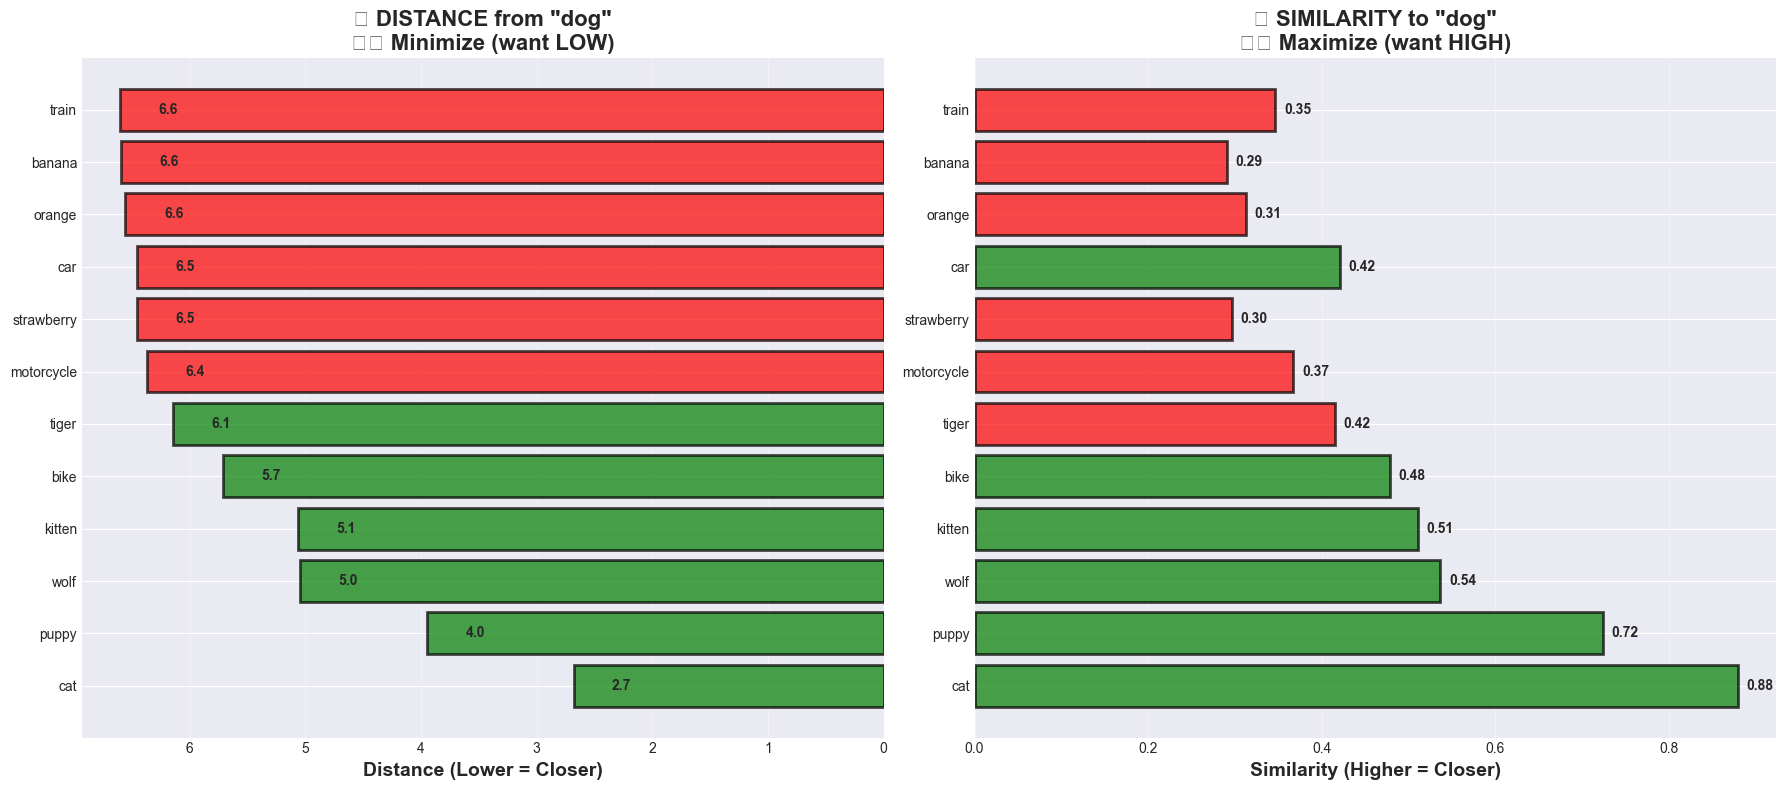


⚡ THE GOLDEN RULE - VISUAL PROOF ⚡

💚 GREEN words on LEFT = GREEN words on RIGHT!
   Low Distance ↔ High Similarity (e.g., puppy, cat, kitten)

❤️  RED words on LEFT = RED words on RIGHT!
   High Distance ↔ Low Similarity (e.g., apple, banana, mango)

💡 They're INVERSE but identify the SAME relationships!


In [10]:
# Get top 12 words by distance
top_words = [w for w, _ in sorted_dist[:12]]

distances_list = [distances[w] for w in top_words]
similarities_list = [similarities[w] for w in top_words]

# Create comparison plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8))

# Distance plot (lower = better)
colors_dist = ['green' if d < np.median(distances_list) else 'red' for d in distances_list]
bars1 = ax1.barh(top_words, distances_list, color=colors_dist, alpha=0.7, edgecolor='black', linewidth=2)
ax1.set_xlabel('Distance (Lower = Closer)', fontsize=14, weight='bold')
ax1.set_title(f'📏 DISTANCE from "{reference_word}"\n⬇️ Minimize (want LOW)',
             fontsize=16, weight='bold')
ax1.invert_xaxis()
ax1.grid(True, alpha=0.3, axis='x')

# Add values
for bar, val in zip(bars1, distances_list):
    width = bar.get_width()
    ax1.text(width - 0.5, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}', ha='right', va='center', fontsize=10, weight='bold')

# Similarity plot (higher = better)
colors_sim = ['green' if s > np.median(similarities_list) else 'red' for s in similarities_list]
bars2 = ax2.barh(top_words, similarities_list, color=colors_sim, alpha=0.7, edgecolor='black', linewidth=2)
ax2.set_xlabel('Similarity (Higher = Closer)', fontsize=14, weight='bold')
ax2.set_title(f'🔗 SIMILARITY to "{reference_word}"\n⬆️ Maximize (want HIGH)',
             fontsize=16, weight='bold')
ax2.grid(True, alpha=0.3, axis='x')

# Add values
for bar, val in zip(bars2, similarities_list):
    width = bar.get_width()
    ax2.text(width + 0.01, bar.get_y() + bar.get_height()/2,
            f'{val:.2f}', ha='left', va='center', fontsize=10, weight='bold')

plt.tight_layout()
plt.show()

print("\n" + "="*70)
print("⚡ THE GOLDEN RULE - VISUAL PROOF ⚡")
print("="*70)
print("\n💚 GREEN words on LEFT = GREEN words on RIGHT!")
print("   Low Distance ↔ High Similarity (e.g., puppy, cat, kitten)\n")
print("❤️  RED words on LEFT = RED words on RIGHT!")
print("   High Distance ↔ Low Similarity (e.g., apple, banana, mango)\n")
print("💡 They're INVERSE but identify the SAME relationships!")
print("="*70)

## 9. Bonus: Word2Vec Analogies

Famous: **king - man + woman = queen**

In [11]:
# Test word analogies
print("🧠 Word2Vec Analogies (Vector Arithmetic):\n")

def analogy(positive, negative, topn=5):
    """
    positive: list of words to add
    negative: list of words to subtract
    """
    try:
        results = model.most_similar(positive=positive, negative=negative, topn=topn)
        return results
    except KeyError as e:
        return f"Word not in vocabulary: {e}"

# Test analogies
analogies_test = [
    (['king', 'woman'], ['man'], 'king - man + woman = ?'),
    (['paris', 'germany'], ['france'], 'paris - france + germany = ?'),
    (['dog', 'kitten'], ['cat'], 'dog - cat + kitten = ?'),
]

for positive, negative, description in analogies_test:
    print(f"\n📝 {description}")
    print("-" * 50)
    results = analogy(positive, negative, topn=3)
    if isinstance(results, list):
        for word, similarity in results:
            print(f"   {word:<15} (similarity: {similarity:.3f})")
    else:
        print(f"   {results}")

print("\n💡 This is the SAME distance/similarity concept at work!")
print("   Word2Vec finds words with similar RELATIONSHIPS in vector space!")

🧠 Word2Vec Analogies (Vector Arithmetic):


📝 king - man + woman = ?
--------------------------------------------------
   queen           (similarity: 0.770)
   monarch         (similarity: 0.684)
   throne          (similarity: 0.676)

📝 paris - france + germany = ?
--------------------------------------------------
   berlin          (similarity: 0.885)
   frankfurt       (similarity: 0.799)
   vienna          (similarity: 0.768)

📝 dog - cat + kitten = ?
--------------------------------------------------
   puppy           (similarity: 0.686)
   rottweiler      (similarity: 0.578)
   puppies         (similarity: 0.565)

💡 This is the SAME distance/similarity concept at work!
   Word2Vec finds words with similar RELATIONSHIPS in vector space!


---
# 🎯 FINAL SUMMARY

## What We Learned with REAL Word2Vec:

### 1. **Real Embeddings**
- Pre-trained Word2Vec captures semantic meaning
- Each word = 100D vector
- Similar words have similar vectors

### 2. **PCA Visualization**
- Reduced 100D → 3D for visualization
- Semantic clusters visible in 3D space
- Similar words cluster together

### 3. **Distance vs Similarity**
```python
# Same words, different metrics:
Low Distance  = High Similarity (puppy, cat, kitten)
High Distance = Low Similarity (apple, banana, orange)
```

### 4. **The Proof**
- **3D plots**: Same colors, opposite meaning
- **Bar charts**: Same GREEN words on both sides
- **Rankings**: Identical order

### 5. **Real Applications**
- Search engines (find similar documents)
- Recommendation systems (find similar products)
- Chatbots (understand word meaning)
- Translation (map words across languages)

---

## 🚀 Key Takeaway:

### Distance and Similarity = **TWO VIEWS OF THE SAME THING** 🪙

**Formula:**
```python
# Euclidean distance
distance = euclidean(vec1, vec2)

# Cosine similarity
similarity = cosine_similarity([vec1], [vec2])[0][0]

# They identify the SAME relationships!
```

**Choose based on:**
- Algorithm requirements
- Field convention
- Interpretability

---

**Now you understand with REAL embeddings! 🎓**